# EDA - Análisis Exploratorio de Datos
**Proyecto: Zona de Interés Au**

In [1]:
import sys
import os
from pathlib import Path
import shutil

project_root = "/workspaces/proyecto-zona-interes-Au"
sys.path.insert(0, project_root)
os.chdir(project_root)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import logger

# Limpiar carpeta output
output_dir = Path("notebooks/output")
if output_dir.exists():
    shutil.rmtree(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

sns.set(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (18, 12)

logger.info("Iniciando EDA completo")
print("Cargando datos procesados...")

Cargando datos procesados...


In [2]:
df = pd.read_csv("data/processed/data_procesada.csv")
print(f"Dataset cargado - Dimensiones: {df.shape}")

Dataset cargado - Dimensiones: (2137, 51)


## 1. Distribución de la Variable Objetivo

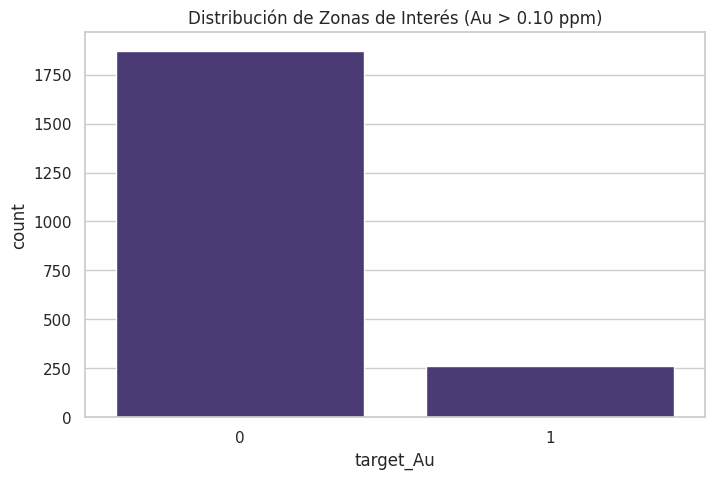

target_Au
0    87.65
1    12.35
Name: proportion, dtype: float64


In [3]:
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x='target_Au')
plt.title('Distribución de Zonas de Interés (Au > 0.10 ppm)')
plt.savefig('notebooks/output/01_distribucion_target.png', dpi=300, bbox_inches='tight')
plt.show()

print(df['target_Au'].value_counts(normalize=True).round(4)*100)

## 2. Mapa Espacial de Muestras

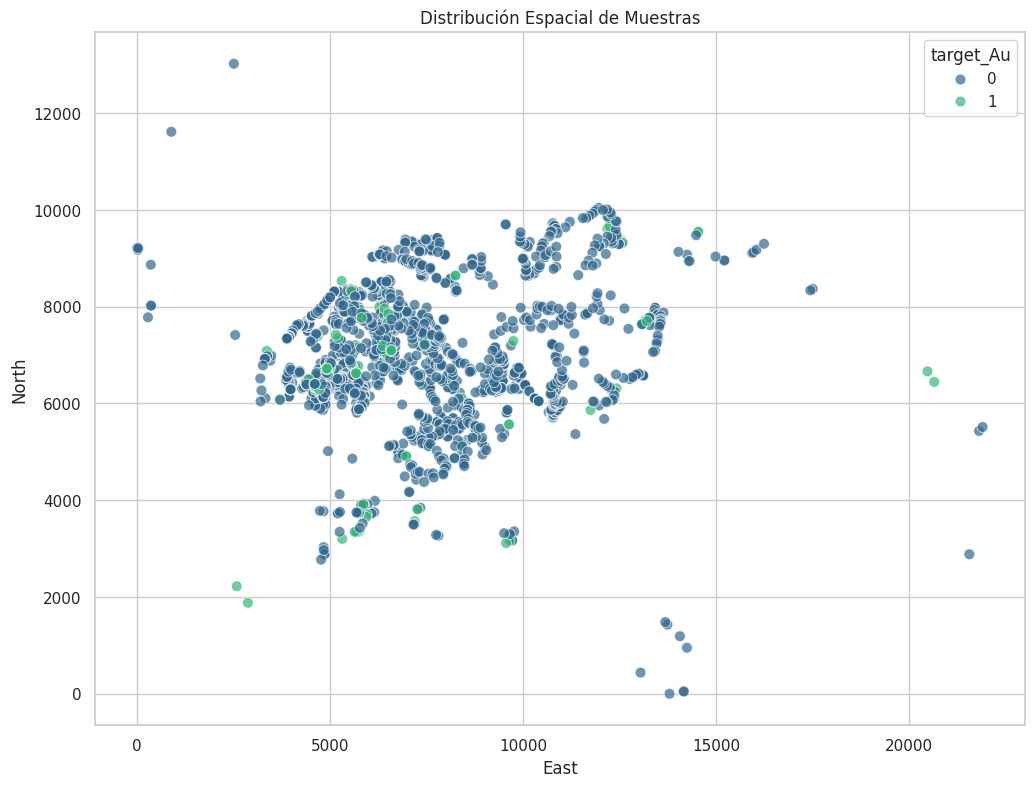

In [4]:
plt.figure(figsize=(12,9))
sns.scatterplot(data=df, x='East', y='North', hue='target_Au', palette='viridis', alpha=0.7, s=60)
plt.title('Distribución Espacial de Muestras')
plt.savefig('notebooks/output/02_mapa_espacial.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Matriz de Correlación

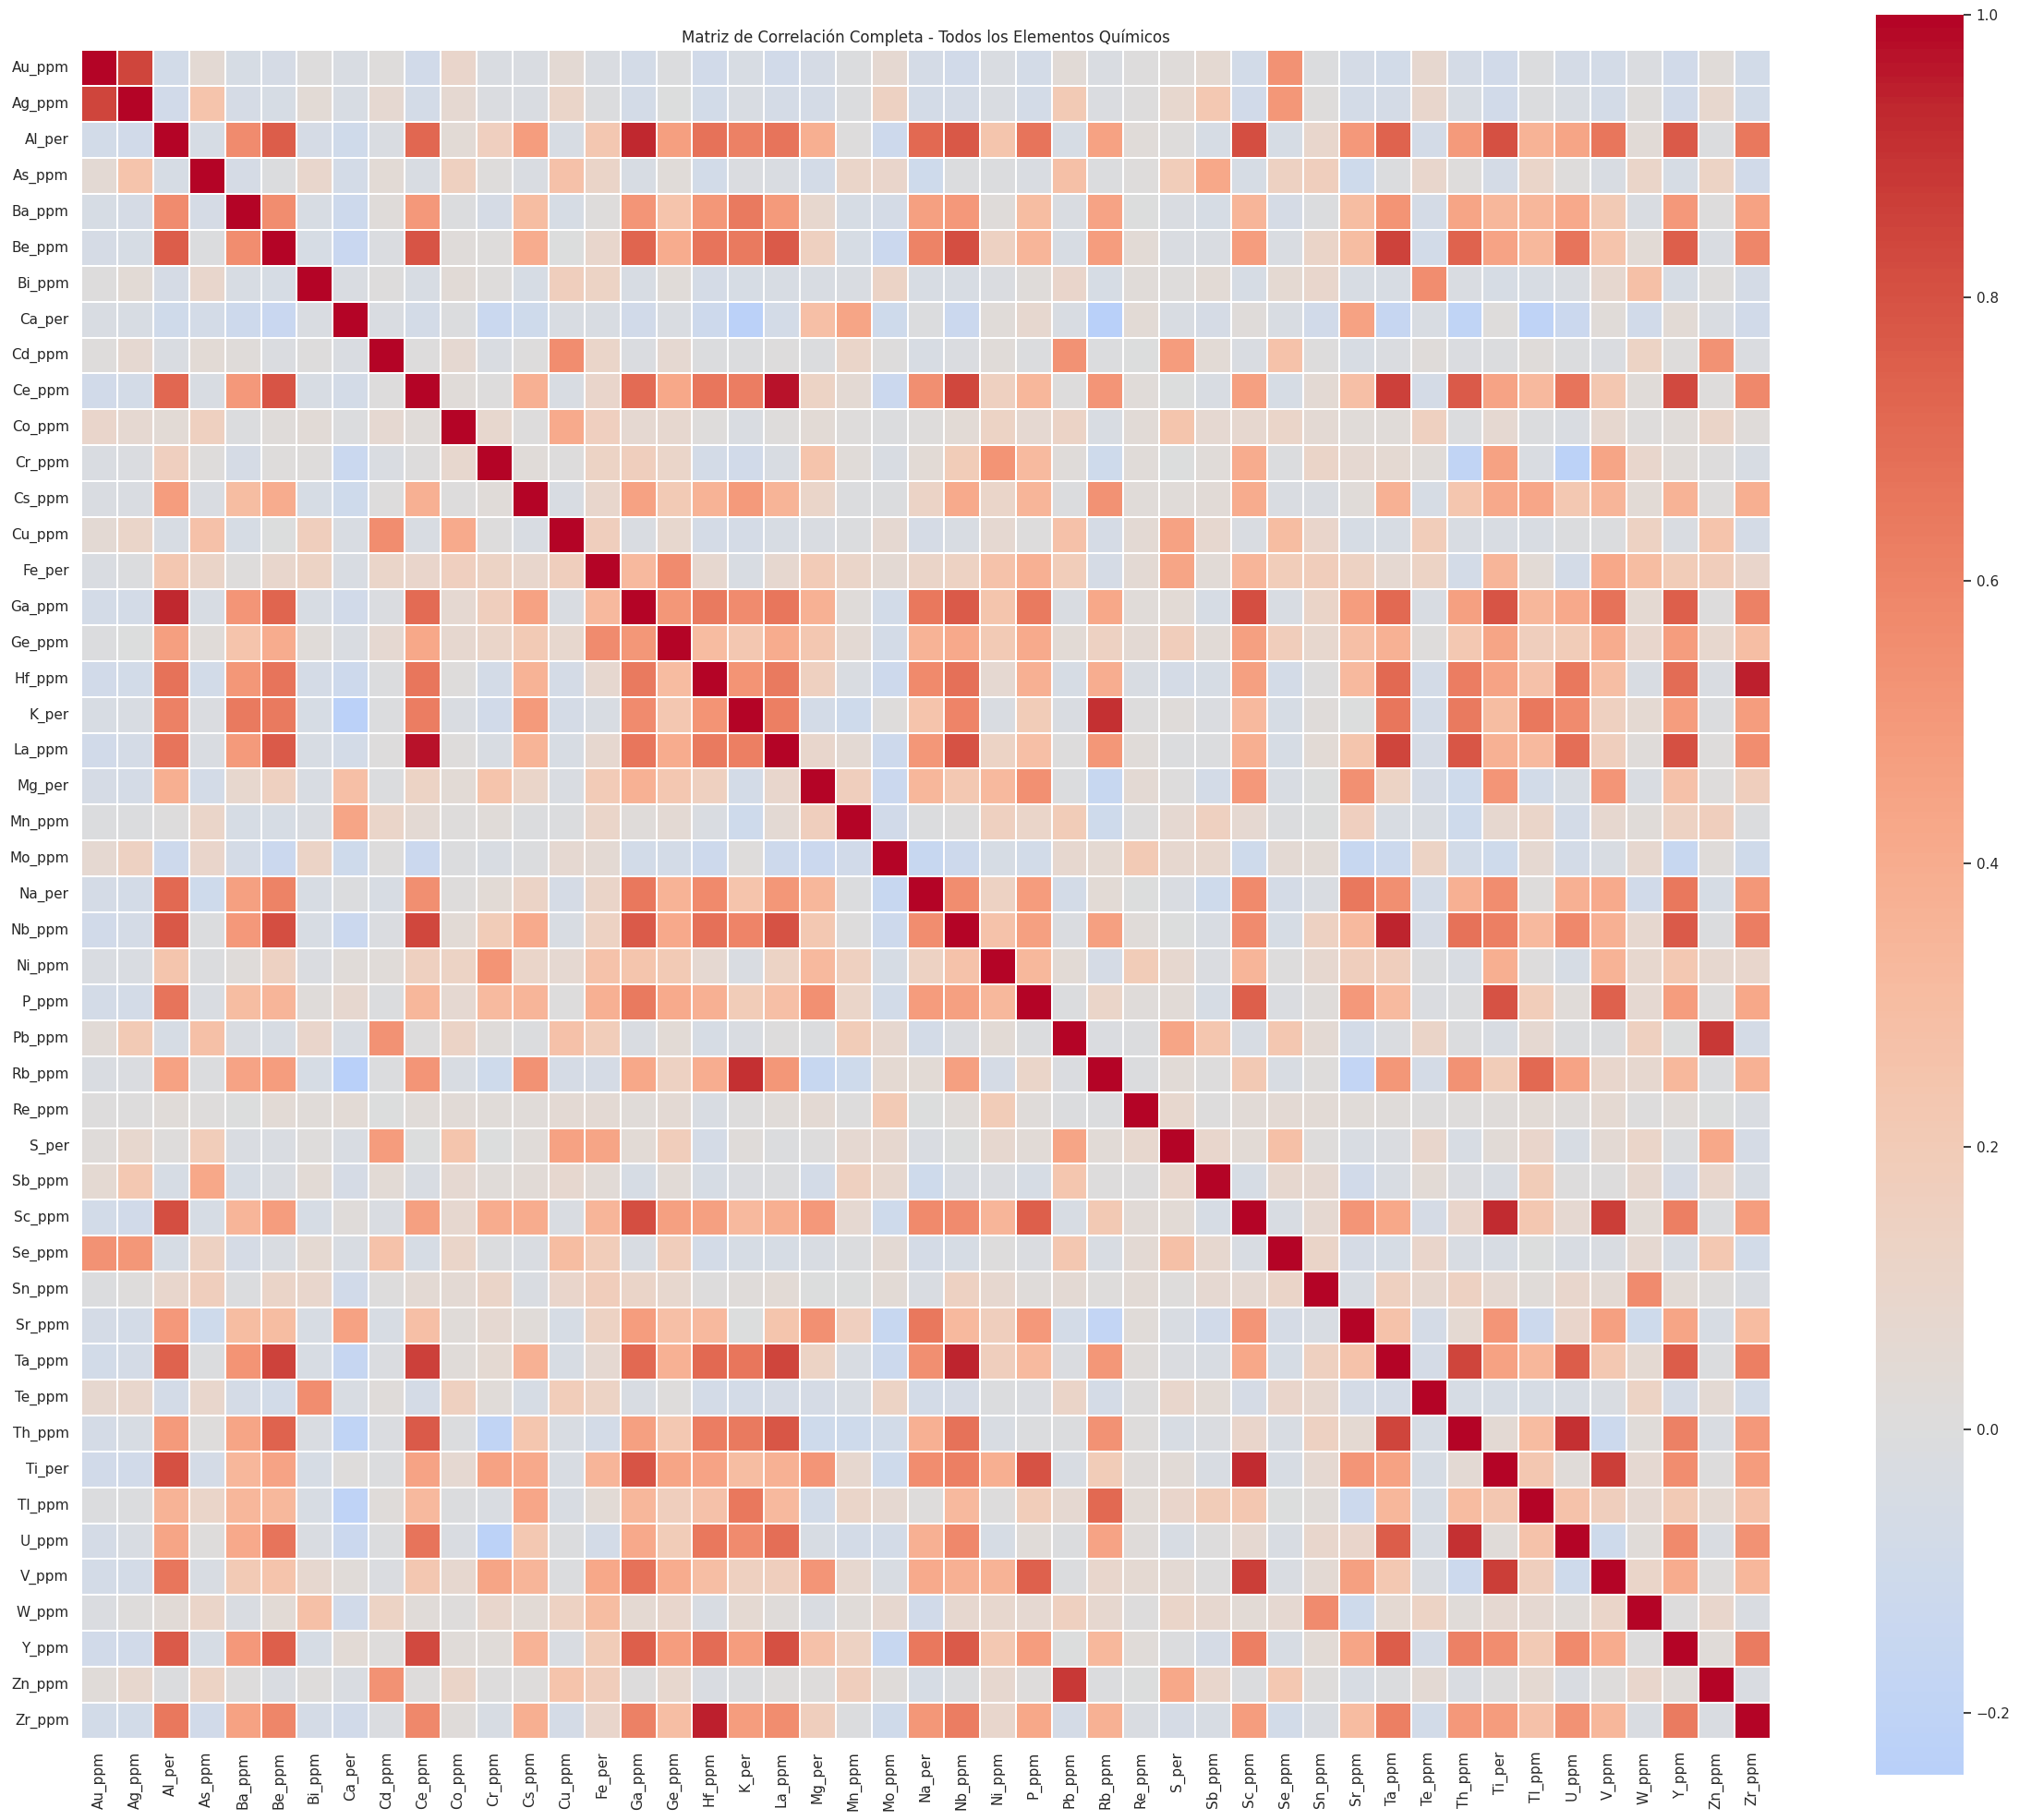

In [5]:
exclude_cols = ['East', 'North', 'Level', 'target_Au']
numeric_cols = [col for col in df.select_dtypes(include=['float64', 'int64']).columns if col not in exclude_cols]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, linewidths=0.2, square=True)
plt.title('Matriz de Correlación Completa - Todos los Elementos Químicos')
plt.tight_layout()
plt.savefig('notebooks/output/03_matriz_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Distribuciones Normales

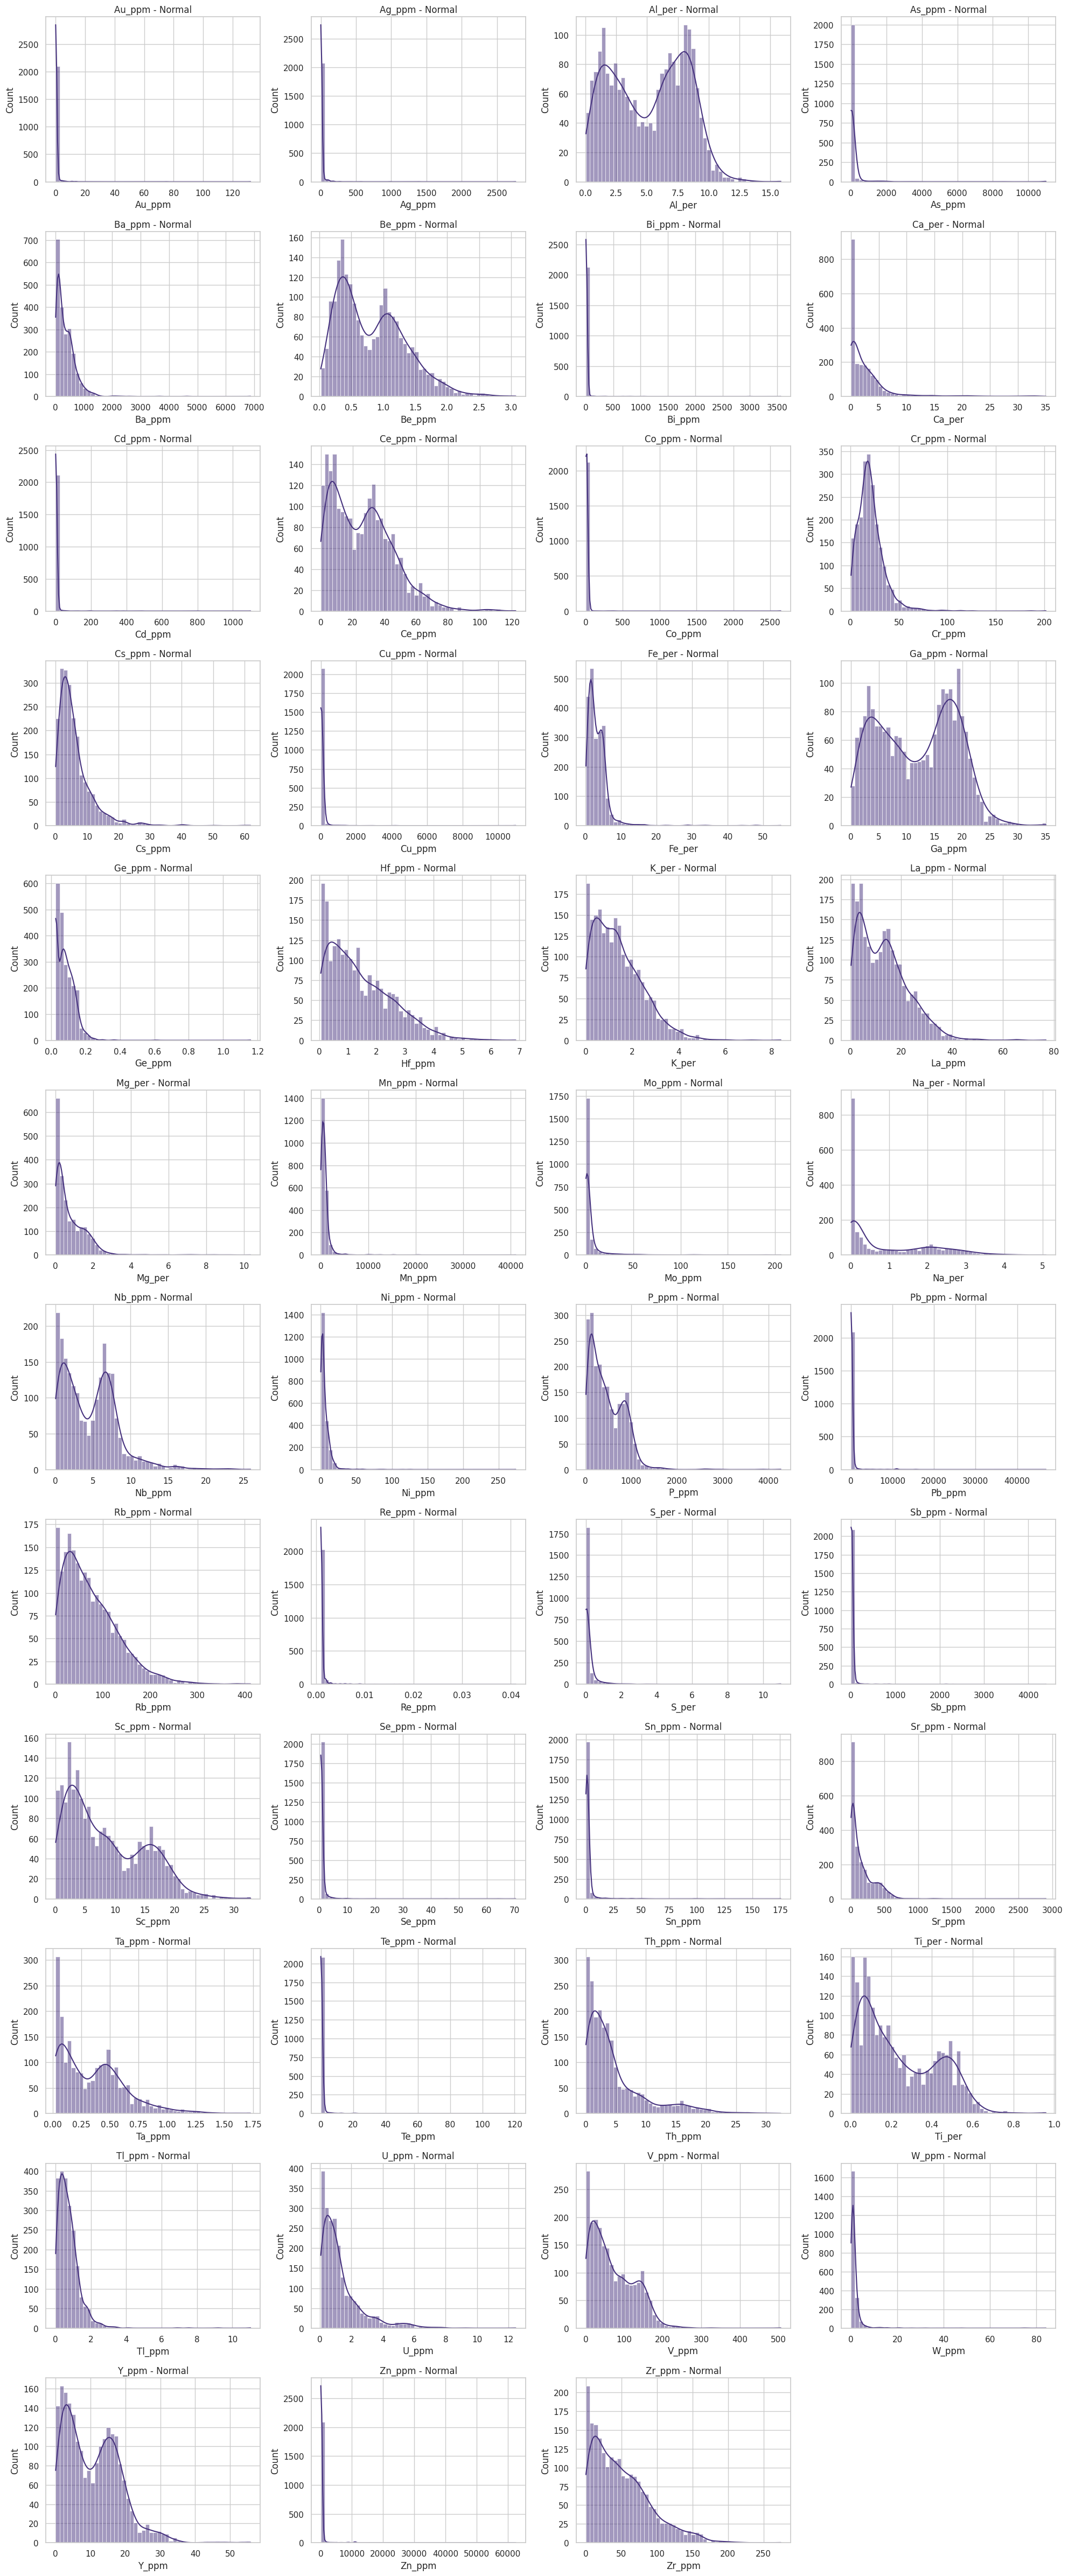

In [6]:
n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(20, n_rows * 4))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f'{col} - Normal')
    plt.xlabel(col)

plt.tight_layout()
plt.savefig('notebooks/output/04_distribuciones_normales.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Distribuciones Lognormales

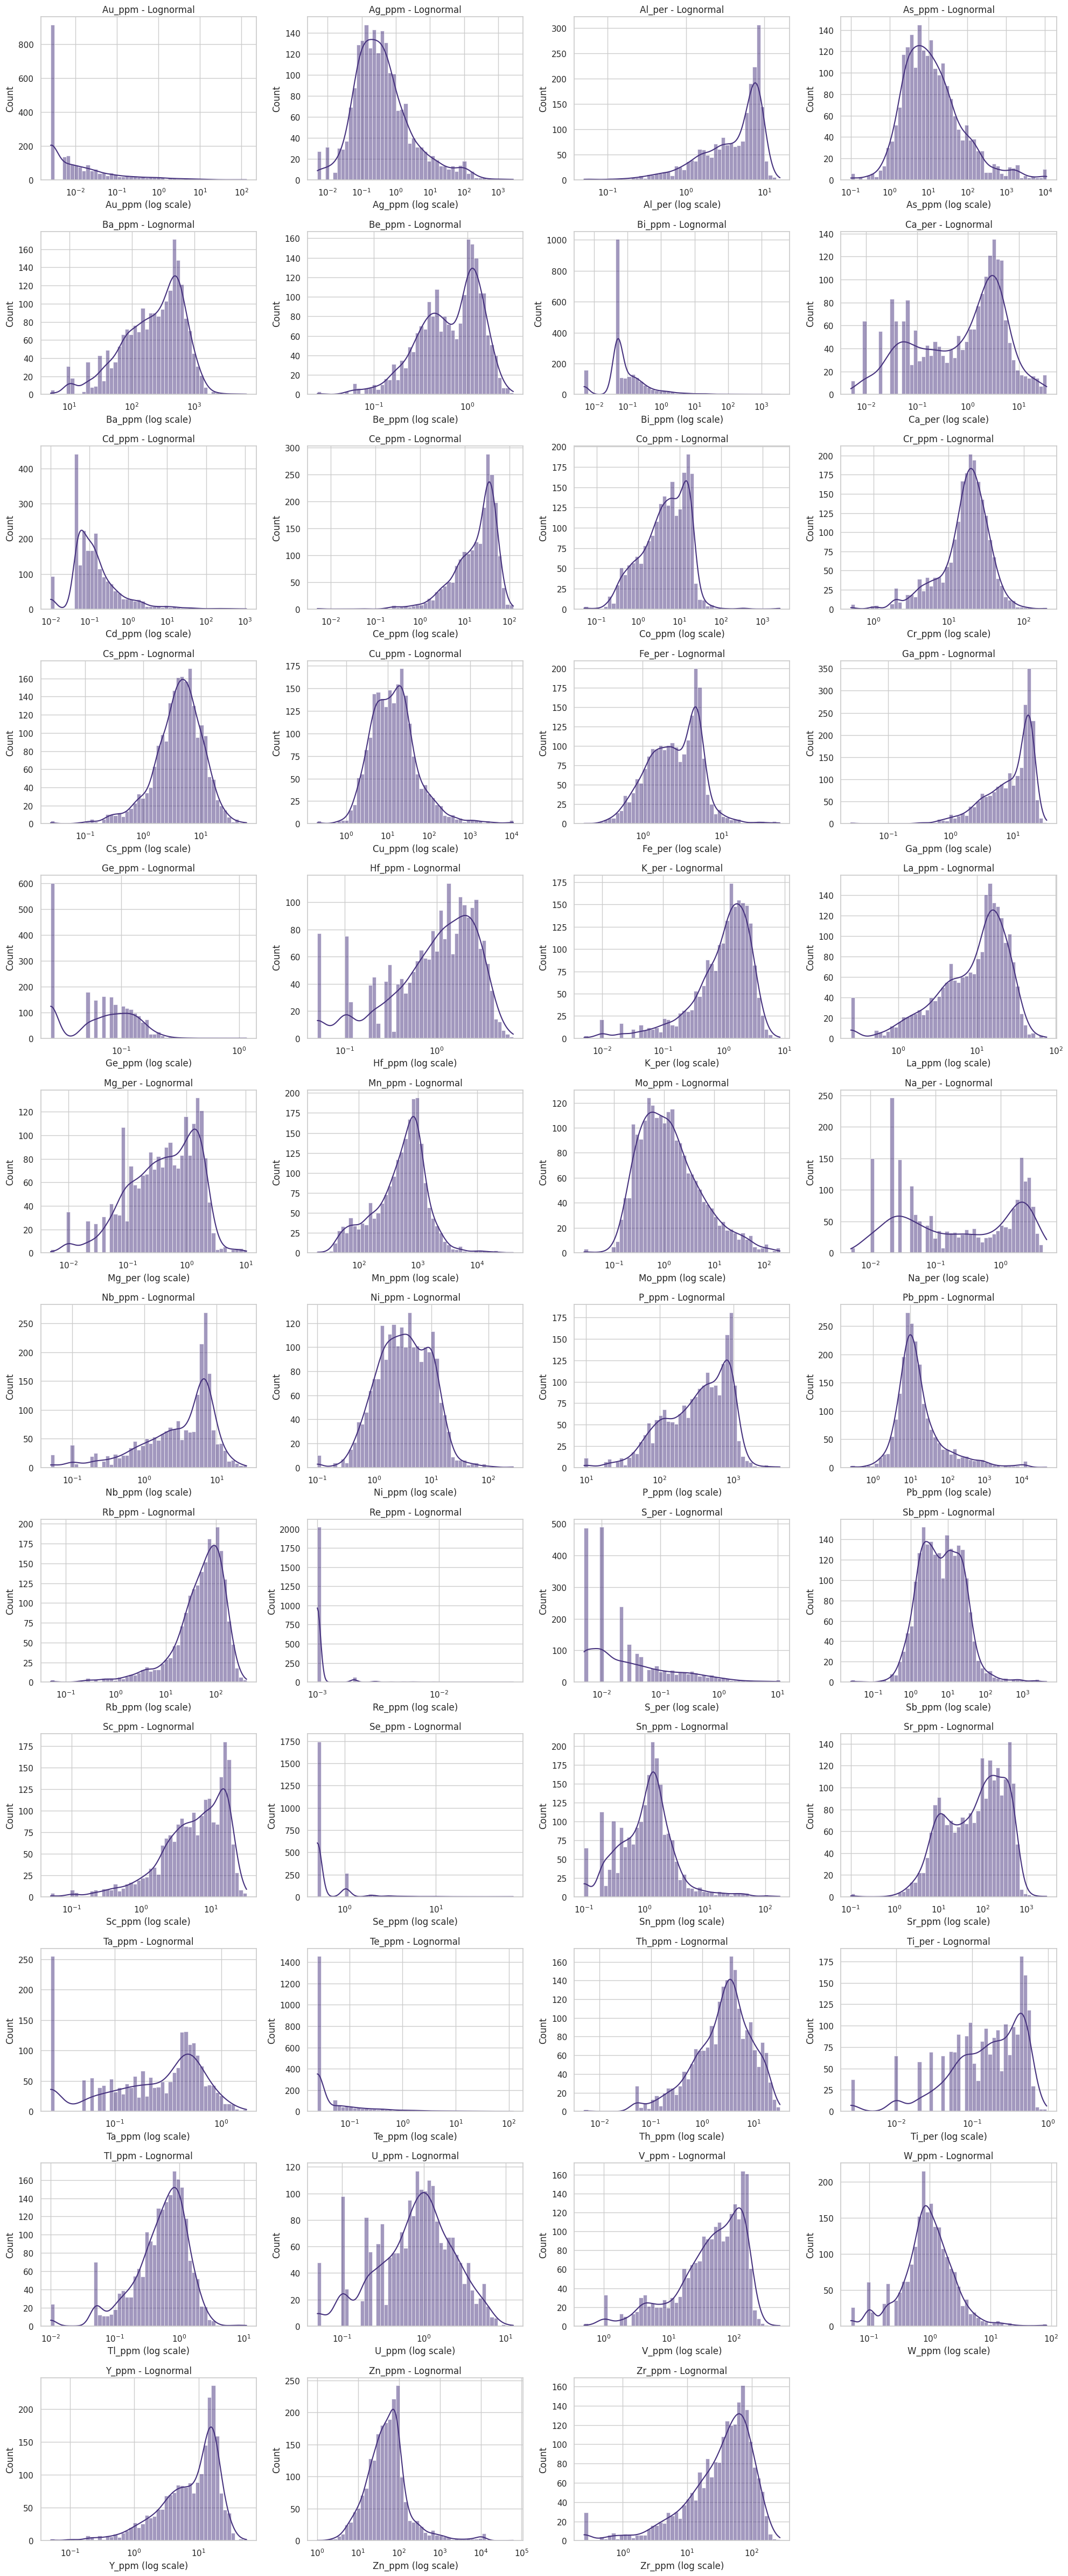

In [7]:
plt.figure(figsize=(20, n_rows * 4))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    data = df[col].dropna()
    if data.min() > 0:
        sns.histplot(data, bins=50, kde=True, log_scale=True)
        plt.title(f'{col} - Lognormal')
        plt.xlabel(f'{col} (log scale)')
    else:
        sns.histplot(data, bins=50, kde=True)
        plt.title(f'{col} - Normal')
        plt.xlabel(col)

plt.tight_layout()
plt.savefig('notebooks/output/05_distribuciones_lognormales.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Resumen Estadístico Completo

In [8]:
print("\n" + "="*100)
print("RESUMEN ESTADÍSTICO COMPLETO")
print("="*100)

stats = df[numeric_cols].describe().round(4)
print(stats)

stats.to_csv('notebooks/output/06_resumen_estadistico.csv')
print("\nResumen guardado en: notebooks/output/06_resumen_estadistico.csv")


RESUMEN ESTADÍSTICO COMPLETO
          Au_ppm     Ag_ppm     Al_per      As_ppm     Ba_ppm     Be_ppm  \
count  2137.0000  2137.0000  2137.0000   2137.0000  2137.0000  2137.0000   
mean      0.3119     7.9209     5.1391    149.5114   352.9714     0.8225   
std       3.4895    74.9324     3.0249    882.3871   356.9178     0.5189   
min       0.0025     0.0050     0.0500      0.1000     5.0000     0.0250   
25%       0.0025     0.1090     2.3100      3.6800   102.9600     0.3800   
50%       0.0060     0.3030     5.5000      9.9600   263.8400     0.7400   
75%       0.0240     1.0200     7.8600     31.1600   511.6400     1.1700   
max     132.2450  2766.9060    15.8500  11000.0000  6874.3400     3.0700   

          Bi_ppm     Ca_per     Cd_ppm     Ce_ppm  ...     Te_ppm     Th_ppm  \
count  2137.0000  2137.0000  2137.0000  2137.0000  ...  2137.0000  2137.0000   
mean      5.9942     2.6631     2.6956    26.1875  ...     0.4943     4.6916   
std     107.8499     4.5539    34.7197    18.